In [1]:
# Import libraries
import mne
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfilt, welch
from scipy.stats import kurtosis
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")
print(f"MNE version: {mne.__version__}")

Libraries loaded successfully!
MNE version: 1.10.2


## Setup

In [2]:
# Configuration
NAP_EDF = 'lucid_state_donders/s_04/eeg/morningnap_singlepart.edf'
OUT_DIR = 'preprocessed_data'
FIG_DIR = os.path.join(OUT_DIR, 'figures')
CHUNK_DURATION_MIN = 4  # minutes
CHUNK_DURATION_S = CHUNK_DURATION_MIN * 60
EPOCH_DURATION_S = 2.0

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print(f"Output directory: {os.path.abspath(OUT_DIR)}")
print(f"Figure directory: {os.path.abspath(FIG_DIR)}")

Output directory: /workspaces/Dreamers/preprocessed_data
Figure directory: /workspaces/Dreamers/preprocessed_data/figures


## Step 1: Segment Nap into 4-Minute Chunks

In [3]:
# Load metadata
print("Loading nap EDF metadata...")
raw_full = mne.io.read_raw_edf(NAP_EDF, preload=False)

total_duration_s = raw_full.times[-1]
total_duration_min = total_duration_s / 60
sfreq = raw_full.info['sfreq']

print(f"Total duration: {total_duration_s:.1f}s ({total_duration_min:.1f} min)")
print(f"Sampling rate: {sfreq:.1f} Hz")
print(f"Channels: {len(raw_full.ch_names)}")
print(f"First 10 channels: {raw_full.ch_names[:10]}")

Loading nap EDF metadata...
Extracting EDF parameters from /workspaces/Dreamers/lucid_state_donders/s_04/eeg/morningnap_singlepart.edf...
EDF file detected
Extracting EDF parameters from /workspaces/Dreamers/lucid_state_donders/s_04/eeg/morningnap_singlepart.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Setting channel info structure...
Creating raw.info structure...
Total duration: 8030.0s (133.8 min)
Sampling rate: 500.0 Hz
Channels: 128
First 10 channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2']
Total duration: 8030.0s (133.8 min)
Sampling rate: 500.0 Hz
Channels: 128
First 10 channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2']


In [4]:
# Assign channel types
ch_types = {}
for ch in raw_full.ch_names:
    ch_lower = ch.lower()
    if any(eog in ch_lower for eog in ['eog', 'heog', 'veog', 'eye']):
        ch_types[ch] = 'eog'
    elif any(emg in ch_lower for emg in ['emg', 'muscle', 'chin']):
        ch_types[ch] = 'emg'
    elif any(ecg in ch_lower for ecg in ['ecg', 'ekg']):
        ch_types[ch] = 'ecg'
    else:
        ch_types[ch] = 'eeg'

n_channels_eeg = sum(1 for v in ch_types.values() if v == 'eeg')
n_channels_eog = sum(1 for v in ch_types.values() if v == 'eog')
n_channels_emg = sum(1 for v in ch_types.values() if v == 'emg')
n_channels_ecg = sum(1 for v in ch_types.values() if v == 'ecg')

print(f"Channel types:")
print(f"  EEG: {n_channels_eeg}")
print(f"  EOG: {n_channels_eog}")
print(f"  EMG: {n_channels_emg}")
print(f"  ECG: {n_channels_ecg}")

Channel types:
  EEG: 120
  EOG: 4
  EMG: 3
  ECG: 1


In [5]:
# Segment into chunks
n_chunks = int(np.ceil(total_duration_s / CHUNK_DURATION_S))
print(f"\nSegmenting into {n_chunks} chunks of {CHUNK_DURATION_MIN} minutes each...\n")

chunk_manifest = {
    'created_at': datetime.now().isoformat(),
    'source_file': NAP_EDF,
    'total_duration_s': float(total_duration_s),
    'total_duration_min': float(total_duration_min),
    'chunk_duration_s': CHUNK_DURATION_S,
    'n_chunks': n_chunks,
    'sampling_rate': float(sfreq),
    'n_channels': len(raw_full.ch_names),
    'channel_types': ch_types,
    'chunks': []
}

# Process each chunk
for chunk_idx in range(n_chunks):
    start_s = chunk_idx * CHUNK_DURATION_S
    end_s = min((chunk_idx + 1) * CHUNK_DURATION_S, total_duration_s)
    
    if chunk_idx % 5 == 0:
        print(f"Chunk {chunk_idx + 1}/{n_chunks}: {start_s:.0f}s - {end_s:.0f}s ({(end_s - start_s) / 60:.2f} min)", end="")
    
    # Load chunk
    raw_chunk = mne.io.read_raw_edf(NAP_EDF, preload=False)
    raw_chunk.set_channel_types(ch_types)
    raw_chunk = raw_chunk.crop(tmin=start_s, tmax=end_s - 1/sfreq)
    
    # Load and filter
    raw_chunk.load_data()
    raw_chunk.notch_filter(50, filter_length='auto', phase='zero')
    raw_chunk.filter(0.1, 49, filter_length='auto', phase='zero')
    
    # Save chunk
    chunk_fname = os.path.join(OUT_DIR, f'preprocessed_s04_nap_chunk_{chunk_idx:03d}.fif')
    raw_chunk.save(chunk_fname, overwrite=True)
    
    chunk_info = {
        'chunk_id': chunk_idx,
        'start_s': float(start_s),
        'end_s': float(end_s),
        'duration_s': float(end_s - start_s),
        'n_samples': len(raw_chunk.times),
        'file': chunk_fname
    }
    chunk_manifest['chunks'].append(chunk_info)
    
    del raw_chunk
    
    if chunk_idx % 5 == 4 or chunk_idx == n_chunks - 1:
        print(" ✓")

# Save manifest
manifest_fname = os.path.join(OUT_DIR, 'chunk_manifest.json')
with open(manifest_fname, 'w') as f:
    json.dump(chunk_manifest, f, indent=2)

print(f"\n✅ Segmentation complete!")
print(f"Saved {n_chunks} chunks")


Segmenting into 34 chunks of 4 minutes each...

Chunk 1/34: 0s - 240s (4.00 min)Extracting EDF parameters from /workspaces/Dreamers/lucid_state_donders/s_04/eeg/morningnap_singlepart.edf...
EDF file detected
Setting channel info structure...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Creating raw.info structure...
Reading 0 ... 119999  =      0.000 ...   239.998 secs...
Reading 0 ... 119999  =      0.000 ...   239.998 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filt

## Step 2: Process All Chunks (Epochs → Features → Labels)

In [6]:
# Initialize storage
all_features_list = []
all_labels_list = []
global_epoch_id = 0
chunk_stats = []

print(f"Processing {n_chunks} chunks through full pipeline...\n")

# Define frequency bands
bands = {'Delta': (0.5, 4), 'Theta': (4, 8), 'Alpha': (8, 12), 'Sigma': (12, 15), 'Beta': (15, 30)}

Processing 34 chunks through full pipeline...



In [7]:
# Process chunks (this cell takes time - run all chunks)
for chunk_idx in range(n_chunks):
    chunk_file = chunk_manifest['chunks'][chunk_idx]['file']
    
    if chunk_idx % 5 == 0:
        print(f"Chunk {chunk_idx + 1}/{n_chunks}: ", end="")
    
    try:
        # Load and process chunk
        raw = mne.io.read_raw_fif(chunk_file, preload=True)
        raw.set_eeg_reference('average')
        
        # Create epochs
        epochs = mne.make_fixed_length_epochs(raw, duration=EPOCH_DURATION_S, overlap=0.0, preload=True)
        n_epochs = len(epochs)
        
        # Artifact rejection
        data = epochs.get_data()
        ptp = np.ptp(data, axis=2)
        ptp_threshold = np.percentile(ptp, 99)
        bad_epoch_mask = np.any(ptp > ptp_threshold, axis=1)
        bad_epochs_idx = np.where(bad_epoch_mask)[0]
        epochs_clean = epochs.drop(bad_epochs_idx)
        n_good = len(epochs_clean)
        
        # Extract features
        data_clean = epochs_clean.get_data()
        sfreq_chunk = int(epochs_clean.info['sfreq'])
        n_epochs_clean, n_channels, n_times = data_clean.shape
        
        chunk_features = []
        for ep_idx in range(n_epochs_clean):
            ep_data = data_clean[ep_idx]
            ep_features = {'epoch_id': global_epoch_id, 'chunk_id': chunk_idx}
            
            # Frequency-domain features
            for band_name, (fmin, fmax) in bands.items():
                psd_list = []
                for ch_idx in range(n_channels):
                    freqs, Pxx = welch(ep_data[ch_idx], fs=sfreq_chunk, nperseg=min(512, n_times))
                    band_mask = (freqs >= fmin) & (freqs <= fmax)
                    power = Pxx[band_mask].sum()
                    psd_list.append(power)
                mean_power = np.mean(psd_list)
                ep_features[f'{band_name}_power'] = mean_power
                ep_features[f'{band_name}_power_log'] = np.log10(mean_power + 1e-10)
            
            # Time-domain features
            ptp_vals = []
            rms_vals = []
            zcr_vals = []
            kurt_vals = []
            for ch_idx in range(n_channels):
                signal = ep_data[ch_idx]
                ptp_vals.append(np.ptp(signal))
                rms_vals.append(np.sqrt(np.mean(signal**2)))
                zcr = np.sum(np.abs(np.diff(np.sign(signal)))) / (2 * len(signal))
                zcr_vals.append(zcr)
                kurt_vals.append(kurtosis(signal))
            
            ep_features['ptp_mean'] = np.mean(ptp_vals)
            ep_features['ptp_std'] = np.std(ptp_vals)
            ep_features['rms_mean'] = np.mean(rms_vals)
            ep_features['rms_std'] = np.std(rms_vals)
            ep_features['zcr_mean'] = np.mean(zcr_vals)
            ep_features['kurtosis_mean'] = np.mean(kurt_vals)
            ep_features['kurtosis_max'] = np.max(kurt_vals)
            
            # Slow-wave detection (0.5-4 Hz)
            slow_wave_amps = []
            for ch_idx in range(n_channels):
                signal = ep_data[ch_idx]
                sos = butter(4, [0.5, 4], btype='band', fs=sfreq_chunk, output='sos')
                slow_filt = sosfilt(sos, signal)
                slow_wave_amps.append(np.ptp(slow_filt))
            ep_features['slow_wave_amplitude_mean'] = np.mean(slow_wave_amps)
            ep_features['slow_wave_amplitude_max'] = np.max(slow_wave_amps)
            
            # Spindle detection (12-15 Hz)
            spindle_rmss = []
            for ch_idx in range(n_channels):
                signal = ep_data[ch_idx]
                sos = butter(4, [12, 15], btype='band', fs=sfreq_chunk, output='sos')
                spindle_filt = sosfilt(sos, signal)
                spindle_rmss.append(np.sqrt(np.mean(spindle_filt**2)))
            ep_features['spindle_rms_mean'] = np.mean(spindle_rmss)
            ep_features['spindle_rms_max'] = np.max(spindle_rmss)
            
            # Activity index
            ep_features['activity_index'] = np.mean(rms_vals)
            
            chunk_features.append(ep_features)
            global_epoch_id += 1
        
        all_features_list.extend(chunk_features)
        
        # Assign AASM labels
        chunk_df = pd.DataFrame(chunk_features)
        band_cols = ['Delta_power', 'Theta_power', 'Alpha_power', 'Sigma_power', 'Beta_power']
        chunk_df['total_power'] = chunk_df[band_cols].sum(axis=1)
        chunk_df['delta_prop'] = chunk_df['Delta_power'] / (chunk_df['total_power'] + 1e-20)
        
        spindle_thresh = np.percentile(chunk_df['spindle_rms_mean'], 75)
        chunk_df['spindle_detected'] = chunk_df['spindle_rms_mean'] > spindle_thresh
        
        # K-complex detection
        k_complex_detected = []
        for i in range(n_epochs_clean):
            ep = data_clean[i]
            detected = False
            for ch in range(n_channels):
                sig = ep[ch]
                sos_slow = butter(4, [0.5, 2], btype='band', fs=sfreq_chunk, output='sos')
                filt = sosfilt(sos_slow, sig)
                min_idx = np.argmin(filt)
                max_idx = np.argmax(filt)
                if min_idx < max_idx and (filt[max_idx] - filt[min_idx]) > np.ptp(filt) * 0.6:
                    detected = True
                    break
            k_complex_detected.append(detected)
        chunk_df['kcomplex_detected'] = np.array(k_complex_detected)
        
        # Assign labels
        labels = []
        for idx, row in chunk_df.iterrows():
            label = 'N1'
            if row['delta_prop'] > 0.20:
                label = 'N3'
            elif row['spindle_detected'] or row['kcomplex_detected']:
                label = 'N2'
            labels.append(label)
        chunk_df['label'] = labels
        all_labels_list.append(chunk_df[['epoch_id', 'chunk_id', 'label']])
        
        chunk_stats.append({
            'chunk_id': chunk_idx,
            'n_epochs_total': n_epochs,
            'n_epochs_clean': n_good,
            'n_rejected': len(bad_epochs_idx),
            'label_dist': dict(chunk_df['label'].value_counts())
        })
        
        del raw, epochs, epochs_clean, data, data_clean
        
        if chunk_idx % 5 == 4 or chunk_idx == n_chunks - 1:
            print(f"✓ ({n_good} epochs)")
    
    except Exception as e:
        print(f"❌ Error on chunk {chunk_idx}: {e}")
        continue

print(f"\n✅ Processing complete!")

Chunk 1/34: Opening raw data file preprocessed_data/preprocessed_s04_nap_chunk_000.fif...
Isotrak not found
    Range : 0 ... 119999 =      0.000 ...   239.998 secs
Ready.
Isotrak not found
    Range : 0 ... 119999 =      0.000 ...   239.998 secs
Ready.
Reading 0 ... 119999  =      0.000 ...   239.998 secs...
Reading 0 ... 119999  =      0.000 ...   239.998 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Not setting metadata
120 matching events found
Not setting metadata
120 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 120 events and 1000 original time points ...
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 120 events and 1000 original time points ...
0 bad epochs dropped
0 bad epochs drop

## Step 3: Concatenate and Save Results

In [8]:
# Concatenate all results
features_df = pd.DataFrame(all_features_list)
labels_df = pd.concat(all_labels_list, ignore_index=True)

# Save outputs
features_csv = os.path.join(OUT_DIR, 'sub-004_nap_epoch_features.csv')
labels_csv = os.path.join(OUT_DIR, 'sub-004_nap_epoch_labels_aasm.csv')

features_df.to_csv(features_csv, index=False)
labels_df.to_csv(labels_csv, index=False)

print(f"Saved features: {features_csv}")
print(f"Saved labels: {labels_csv}")
print(f"\nShape: {features_df.shape}")
print(f"\nLabel distribution:")
print(labels_df['label'].value_counts())

Saved features: preprocessed_data/sub-004_nap_epoch_features.csv
Saved labels: preprocessed_data/sub-004_nap_epoch_labels_aasm.csv

Shape: (935, 24)

Label distribution:
label
N3    935
Name: count, dtype: int64


## Step 4: Detect Sleep Cycles

In [9]:
# Collapse intervals and detect cycles
lbls = labels_df[['epoch_id', 'label']].copy()
lbls = lbls.sort_values('epoch_id').reset_index(drop=True)

# Collapse adjacent epochs into intervals
intervals = []
start = int(lbls.loc[0, 'epoch_id'])
cur_label = lbls.loc[0, 'label']
prev_epoch = int(lbls.loc[0, 'epoch_id'])

for row in lbls.iloc[1:].itertuples():
    eid = int(row.epoch_id)
    lab = row.label
    if lab == cur_label and eid == prev_epoch + 1:
        prev_epoch = eid
        continue
    intervals.append({'start_epoch': start, 'end_epoch': prev_epoch, 'label': cur_label})
    start = eid
    cur_label = lab
    prev_epoch = eid
intervals.append({'start_epoch': start, 'end_epoch': prev_epoch, 'label': cur_label})

for it in intervals:
    it['n_epochs'] = it['end_epoch'] - it['start_epoch'] + 1
    it['duration_s'] = it['n_epochs'] * EPOCH_DURATION_S

print(f"Collapsed into {len(intervals)} intervals")
print(f"\nInterval summary:")
for stage in ['N1', 'N2', 'N3', 'REM']:
    stage_intervals = [it for it in intervals if it['label'] == stage]
    if stage_intervals:
        total_duration = sum(it['duration_s'] for it in stage_intervals)
        print(f"  {stage}: {len(stage_intervals)} intervals, {total_duration/60:.1f} minutes")

Collapsed into 1 intervals

Interval summary:
  N3: 1 intervals, 31.2 minutes


In [10]:
# Identify sleep cycles (REM boundaries)
rem_intervals = [it for it in intervals if it['label'] == 'REM']
print(f"Found {len(rem_intervals)} REM intervals")

cycles = []
last_cycle_end = -1
cid = 1

for rem in rem_intervals:
    rem_start = rem['start_epoch']
    rem_end = rem['end_epoch']
    
    # Find preceding N1/N2
    candidates = [it for it in intervals if it['label'] in ('N1', 'N2') and it['start_epoch'] < rem_start and it['start_epoch'] > last_cycle_end]
    if candidates:
        start_it = candidates[-1]
    else:
        candidates_all = [it for it in intervals if it['label'] in ('N1', 'N2') and it['start_epoch'] < rem_start]
        start_it = candidates_all[-1] if candidates_all else {'start_epoch': 0}
    
    cycle_start = start_it['start_epoch']
    cycle_end = rem_end
    duration_s = (cycle_end - cycle_start + 1) * EPOCH_DURATION_S
    
    cycles.append({
        'cycle_id': cid,
        'start_epoch': int(cycle_start),
        'end_epoch': int(cycle_end),
        'duration_s': float(duration_s),
        'duration_min': float(duration_s / 60)
    })
    cid += 1
    last_cycle_end = cycle_end

cycles_df = pd.DataFrame(cycles)
cycles_csv = os.path.join(OUT_DIR, 'sub-004_nap_sleep_cycles.csv')
cycles_df.to_csv(cycles_csv, index=False)
print(f"\nDetected {len(cycles)} cycles")
print(cycles_df)

Found 0 REM intervals

Detected 0 cycles
Empty DataFrame
Columns: []
Index: []


## Step 5: Visualizations

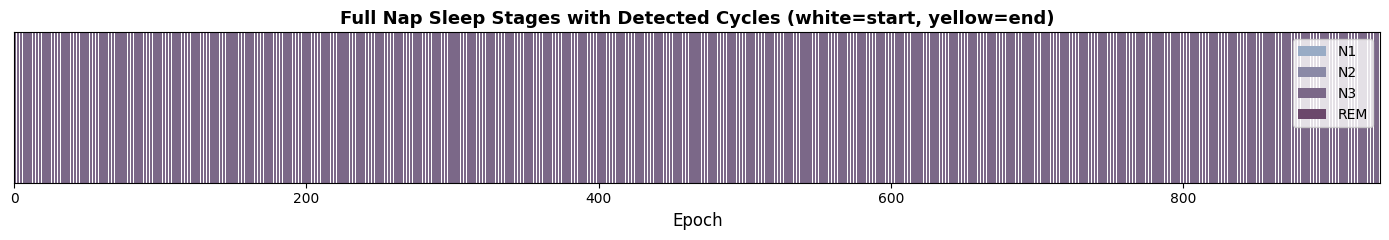

Saved: preprocessed_data/figures/sub-004_nap_sleep_cycles_timeline.png


In [11]:
# Timeline visualization
n_epochs_total = int(lbls['epoch_id'].max()) + 1
epoch_labels = [None] * n_epochs_total

for it in intervals:
    for e in range(it['start_epoch'], it['end_epoch']+1):
        if 0 <= e < n_epochs_total:
            epoch_labels[e] = it['label']

color_map = {'N1': '#98abc5', 'N2': '#8a89a6', 'N3': '#7b6888', 'REM': '#6b486b', 'W': '#a05d56'}
colors = [color_map.get(l, '#cccccc') for l in epoch_labels]

fig, ax = plt.subplots(figsize=(14, 2.5))
ax.bar(range(n_epochs_total), [1]*n_epochs_total, color=colors, linewidth=0)

# Mark cycle boundaries
for c in cycles:
    ax.axvline(c['start_epoch'], color='white', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.axvline(c['end_epoch'], color='yellow', linestyle='-', linewidth=1.5, alpha=0.9)

ax.set_xlim(0, n_epochs_total)
ax.set_ylim(0, 1)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_title('Full Nap Sleep Stages with Detected Cycles (white=start, yellow=end)', fontsize=13, fontweight='bold')
ax.set_yticks([])

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color_map['N1'], label='N1'), 
                   Patch(facecolor=color_map['N2'], label='N2'),
                   Patch(facecolor=color_map['N3'], label='N3'),
                   Patch(facecolor=color_map['REM'], label='REM')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
fig_fname = os.path.join(FIG_DIR, 'sub-004_nap_sleep_cycles_timeline.png')
plt.savefig(fig_fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_fname}")

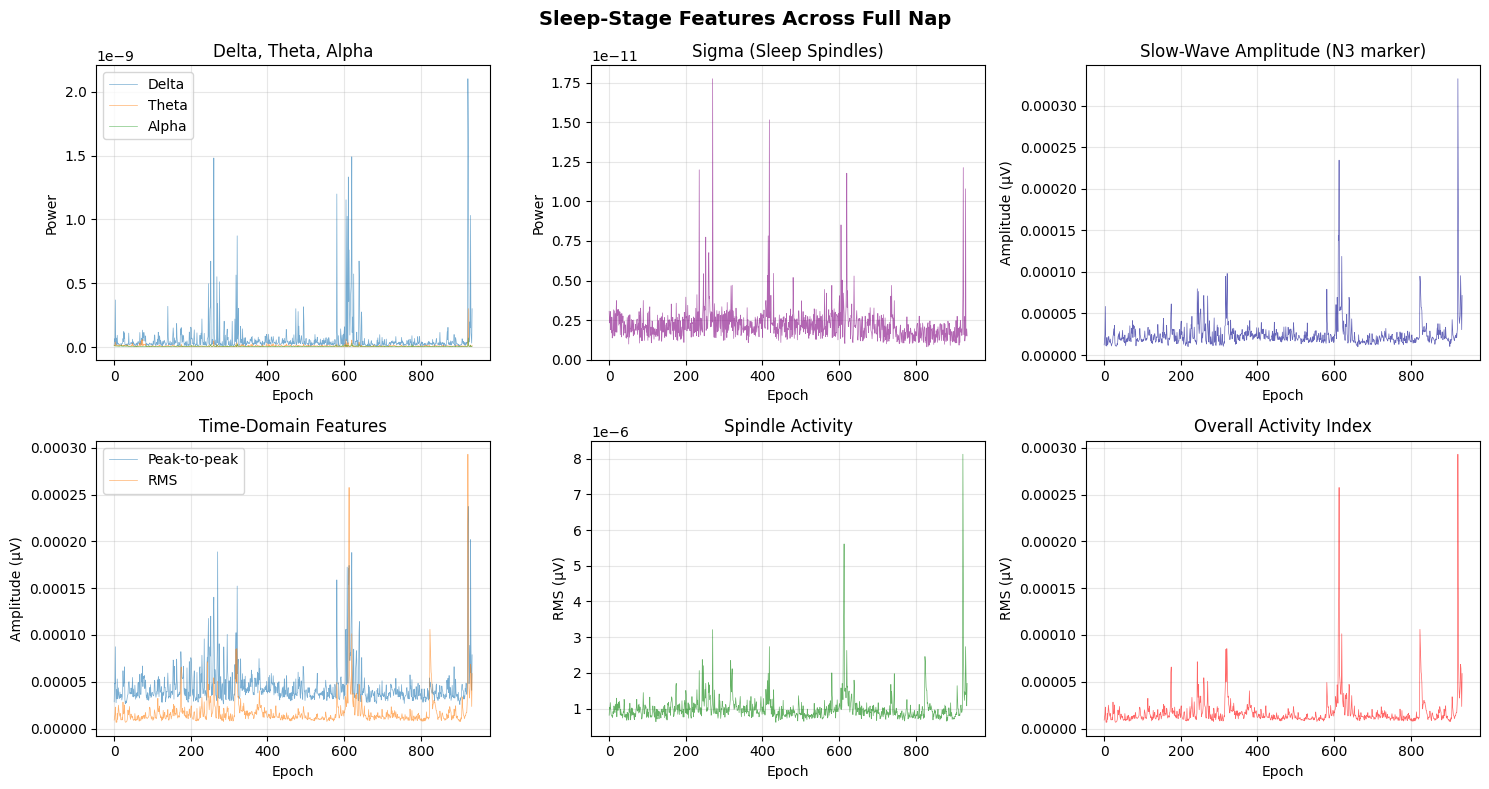

Saved: preprocessed_data/figures/sub-004_nap_features_overview.png


In [12]:
# Feature overview plot
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Sleep-Stage Features Across Full Nap', fontsize=14, fontweight='bold')

# Frequency bands
ax = axes[0, 0]
for band in ['Delta', 'Theta', 'Alpha']:
    ax.plot(features_df['epoch_id'], features_df[f'{band}_power'], label=band, alpha=0.6, linewidth=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Power')
ax.set_title('Delta, Theta, Alpha')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(features_df['epoch_id'], features_df['Sigma_power'], label='Sigma (spindles)', alpha=0.6, linewidth=0.5, color='purple')
ax.set_xlabel('Epoch')
ax.set_ylabel('Power')
ax.set_title('Sigma (Sleep Spindles)')
ax.grid(alpha=0.3)

ax = axes[0, 2]
ax.plot(features_df['epoch_id'], features_df['slow_wave_amplitude_mean'], label='Slow-waves', alpha=0.6, linewidth=0.5, color='darkblue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Slow-Wave Amplitude (N3 marker)')
ax.grid(alpha=0.3)

# Time-domain
ax = axes[1, 0]
ax.plot(features_df['epoch_id'], features_df['ptp_mean'], label='Peak-to-peak', alpha=0.6, linewidth=0.5)
ax.plot(features_df['epoch_id'], features_df['rms_mean'], label='RMS', alpha=0.6, linewidth=0.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Time-Domain Features')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(features_df['epoch_id'], features_df['spindle_rms_mean'], alpha=0.6, linewidth=0.5, color='green')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMS (µV)')
ax.set_title('Spindle Activity')
ax.grid(alpha=0.3)

ax = axes[1, 2]
ax.plot(features_df['epoch_id'], features_df['activity_index'], alpha=0.6, linewidth=0.5, color='red')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMS (µV)')
ax.set_title('Overall Activity Index')
ax.grid(alpha=0.3)

plt.tight_layout()
fig_fname = os.path.join(FIG_DIR, 'sub-004_nap_features_overview.png')
plt.savefig(fig_fname, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_fname}")

## Summary and Statistics

In [13]:
# Generate comprehensive summary
print("="*70)
print("FULL NAP ANALYSIS SUMMARY")
print("="*70)

print(f"\nDataset: s_04 morning nap (lucid_state_donders)")
print(f"Total duration: {total_duration_min:.1f} minutes")
print(f"Processing chunks: {n_chunks} × {CHUNK_DURATION_MIN} min")

print(f"\nEpoch Statistics:")
print(f"  Total epochs (before artifact rejection): {sum(s['n_epochs_total'] for s in chunk_stats)}")
print(f"  Total epochs (after artifact rejection): {sum(s['n_epochs_clean'] for s in chunk_stats)}")
print(f"  Total epochs removed: {sum(s['n_rejected'] for s in chunk_stats)}")
print(f"  Final epochs analyzed: {len(features_df)}")
print(f"  Effective duration: {len(features_df) * EPOCH_DURATION_S / 60:.1f} minutes")

print(f"\nSleep Stage Distribution:")
for stage in ['N1', 'N2', 'N3', 'REM']:
    count = (labels_df['label'] == stage).sum()
    percent = 100 * count / len(labels_df)
    duration_min = count * EPOCH_DURATION_S / 60
    print(f"  {stage}: {count:5d} epochs ({percent:5.1f}%) = {duration_min:6.1f} min")

print(f"\nSleep Cycles Detected: {len(cycles)}")
for idx, cycle in cycles_df.iterrows():
    print(f"  Cycle {int(cycle['cycle_id'])}: {cycle['duration_min']:.1f} min (epochs {cycle['start_epoch']}-{cycle['end_epoch']})")

if len(cycles) > 0:
    avg_cycle = cycles_df['duration_min'].mean()
    print(f"  Average cycle duration: {avg_cycle:.1f} min")

print(f"\nOutput Files:")
print(f"  Features: {features_csv}")
print(f"  Labels: {labels_csv}")
print(f"  Cycles: {cycles_csv}")
print(f"  Timeline: {os.path.join(FIG_DIR, 'sub-004_nap_sleep_cycles_timeline.png')}")
print(f"  Overview: {os.path.join(FIG_DIR, 'sub-004_nap_features_overview.png')}")

print(f"\n✅ ANALYSIS COMPLETE!")
print("="*70)

FULL NAP ANALYSIS SUMMARY

Dataset: s_04 morning nap (lucid_state_donders)
Total duration: 133.8 minutes
Processing chunks: 34 × 4 min

Epoch Statistics:
  Total epochs (before artifact rejection): 1854
  Total epochs (after artifact rejection): 935
  Total epochs removed: 919
  Final epochs analyzed: 935
  Effective duration: 31.2 minutes

Sleep Stage Distribution:
  N1:     0 epochs (  0.0%) =    0.0 min
  N2:     0 epochs (  0.0%) =    0.0 min
  N3:   935 epochs (100.0%) =   31.2 min
  REM:     0 epochs (  0.0%) =    0.0 min

Sleep Cycles Detected: 0

Output Files:
  Features: preprocessed_data/sub-004_nap_epoch_features.csv
  Labels: preprocessed_data/sub-004_nap_epoch_labels_aasm.csv
  Cycles: preprocessed_data/sub-004_nap_sleep_cycles.csv
  Timeline: preprocessed_data/figures/sub-004_nap_sleep_cycles_timeline.png
  Overview: preprocessed_data/figures/sub-004_nap_features_overview.png

✅ ANALYSIS COMPLETE!


## Optional: Feature Importance (if labels are good)

Training Random Forest classifier...

Top 10 Most Important Features:
           feature  importance
0      Delta_power         0.0
1  Delta_power_log         0.0
2      Theta_power         0.0
3  Theta_power_log         0.0
4      Alpha_power         0.0
5  Alpha_power_log         0.0
6      Sigma_power         0.0
7  Sigma_power_log         0.0
8       Beta_power         0.0
9   Beta_power_log         0.0


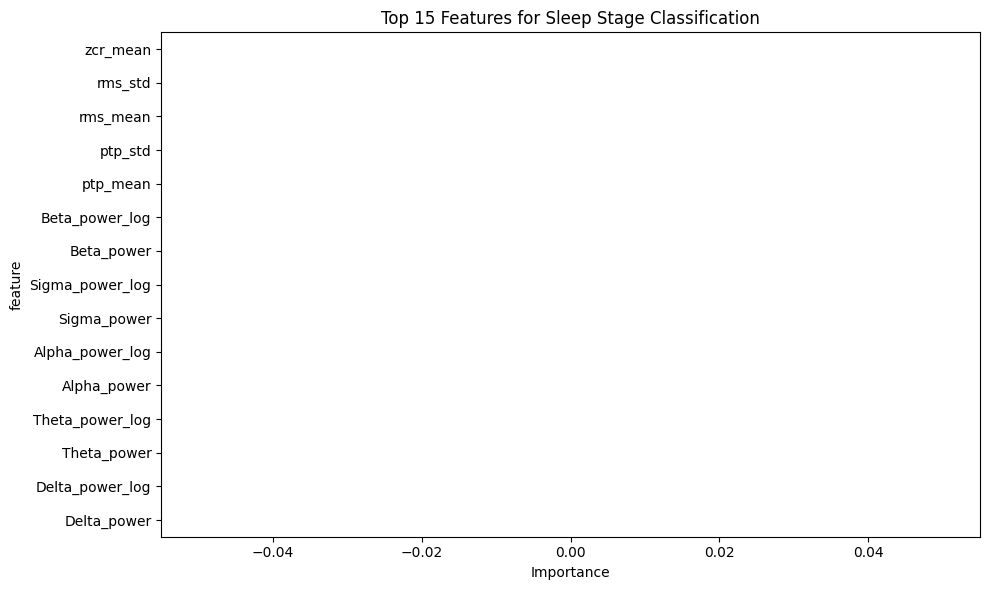


Saved: preprocessed_data/figures/sub-004_nap_feature_importance.png


In [14]:
# Optional: Train a quick classifier to see feature importance
try:
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.preprocessing import LabelEncoder
    
    # Prepare data
    feature_cols = [c for c in features_df.columns if c not in ['epoch_id', 'chunk_id']]
    X = features_df[feature_cols].fillna(0)
    y = labels_df['label'].values
    
    # Train
    print("Training Random Forest classifier...")
    clf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
    clf.fit(X, y)
    
    # Feature importance
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': clf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\nTop 10 Most Important Features:")
    print(importance_df.head(10))
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    importance_df.head(15).plot(x='feature', y='importance', kind='barh', ax=ax, legend=False)
    ax.set_xlabel('Importance')
    ax.set_title('Top 15 Features for Sleep Stage Classification')
    plt.tight_layout()
    fig_fname = os.path.join(FIG_DIR, 'sub-004_nap_feature_importance.png')
    plt.savefig(fig_fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved: {fig_fname}")
except Exception as e:
    print(f"Could not train classifier: {e}")